# Paso 3 — Codificación, métricas y primer modelo

El cuaderno anterior dejó tres archivos preparados en `datos/procesado/`. Este
recorre las decisiones que hay que tomar antes de poder entrenar, entrena el
primer modelo y lo evalúa.

**Cada decisión se justifica frente a las alternativas que se descartaron.** No
basta con saber qué se hizo: importa por qué eso y no otra cosa.

## Las preguntas de este cuaderno

1. **¿Cómo se convierten en números las columnas de texto?**
   Hay cuatro formas razonables y no dan el mismo resultado.

2. **¿Con qué métrica se mide?**
   La respuesta obvia —accuracy— es la equivocada, y aquí se demuestra con un
   modelo que no aprende nada.

3. **¿Qué modelo se usa como punto de partida?**
   Se comparan dos familias y se explica por qué gana una.

4. **¿Cuánto costaba la fuga que se encontró en el paso 2?**
   La respuesta no es la esperada, y al investigarla aparece **un tercer
   problema del dataset** que no se había visto.


## 0. Punto de partida

Se cargan los tres conjuntos que produjo el cuaderno anterior. Conviene recordar
qué es cada uno:

| Conjunto | Filas | Qué es |
|---|---|---|
| `train` | 96 822 | Entrenamiento sin filas duplicadas |
| `test_oficial` | 82 332 | La división que trae el dataset, **con un 25,3 % de fuga** |
| `test_limpio` | 47 716 | Sin las filas que ya estaban en entrenamiento |

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESADO = RAIZ / "datos" / "procesado"
RESULTADOS = RAIZ / "resultados"
RESULTADOS.mkdir(exist_ok=True)

ACENTO = "#5E6AD2"
AVISO = "#e0803c"
GRIS = "#8A8F98"

OBJETIVO = "attack_cat"
CATEGORICAS = ["proto", "service", "state"]

pd.set_option("display.width", 160)

train = pd.read_parquet(PROCESADO / "train.parquet")
test_oficial = pd.read_parquet(PROCESADO / "test_oficial.parquet")
test_limpio = pd.read_parquet(PROCESADO / "test_limpio.parquet")

# Las características son todas las columnas menos las dos etiquetas.
CARACTERISTICAS = [c for c in train.columns if c not in (OBJETIVO, "label")]

print(f"train        {len(train):>7,} filas")
print(f"test_oficial {len(test_oficial):>7,} filas")
print(f"test_limpio  {len(test_limpio):>7,} filas")
print(f"\nCaracterísticas: {len(CARACTERISTICAS)}")

train         96,822 filas
test_oficial  82,332 filas
test_limpio   47,716 filas

Características: 34


---

# 1. Cómo convertir el texto en números

Los modelos de scikit-learn trabajan con números. Tres columnas del dataset son
texto y hay que transformarlas: `proto` (el protocolo de red), `service` (el
servicio) y `state` (el estado de la conexión).

Antes de elegir el método hay que mirar **cuántos valores distintos tiene cada
una**. Ese número, la *cardinalidad*, es lo que determina qué técnicas son
viables.

In [2]:
cardinalidad = pd.DataFrame({
    "en_train": [train[c].nunique() for c in CATEGORICAS],
    "en_test_limpio": [test_limpio[c].nunique() for c in CATEGORICAS],
}, index=CATEGORICAS)

# Categorías que aparecen en prueba pero nunca se vieron durante el entrenamiento.
cardinalidad["nuevas_en_test"] = [
    len(set(test_limpio[c].unique()) - set(train[c].unique())) for c in CATEGORICAS
]
cardinalidad

,en_train,en_test_limpio,nuevas_en_test
proto,133,128,0
service,13,13,0
state,9,7,2


In [3]:
# Qué categorías concretas son esas que el modelo nunca ha visto.
for c in CATEGORICAS:
    nuevas = sorted(set(test_limpio[c].unique()) - set(train[c].unique()))
    if nuevas:
        afectadas = test_limpio[c].isin(nuevas).sum()
        print(f"{c}: {nuevas} → afectan a {afectadas} filas de test_limpio")

state: ['ACC', 'CLO'] → afectan a 5 filas de test_limpio


### Qué se ve aquí

Dos cosas que condicionan todo lo que viene después:

**`proto` tiene 133 valores distintos.** No es una columna categórica pequeña
como `service` (13) o `state` (9). Es casi un identificador.

**`state` tiene dos categorías en prueba que no existen en entrenamiento: `ACC`
y `CLO`.** Solo afectan a 5 filas, así que su impacto en las métricas es nulo —
pero eso es justo lo que las hace peligrosas. Un codificador que no contemple
valores desconocidos **no falla en las métricas: falla lanzando una excepción**.
Con 5 filas entre 47 716 el problema pasa desapercibido en desarrollo y aparece
el día que esto clasifique tráfico real.

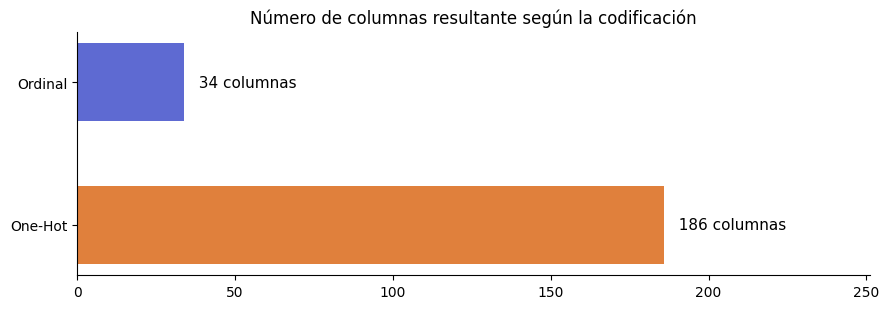

In [4]:
# Cuánto ocuparía cada estrategia de codificación.
columnas_ordinal = len(CARACTERISTICAS)
columnas_onehot = len(CARACTERISTICAS) - len(CATEGORICAS) + sum(
    train[c].nunique() for c in CATEGORICAS
)

fig, ax = plt.subplots(figsize=(9, 3.2))
barras = ax.barh(
    ["One-Hot", "Ordinal"],
    [columnas_onehot, columnas_ordinal],
    color=[AVISO, ACENTO],
    height=0.55,
)
ax.bar_label(barras, labels=[f"  {columnas_onehot} columnas", f"  {columnas_ordinal} columnas"],
             padding=3, fontsize=11)
ax.set_xlim(0, columnas_onehot * 1.35)
ax.set_title("Número de columnas resultante según la codificación")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(RESULTADOS / "codificacion-columnas.png", dpi=140)
plt.show()

### Las cuatro opciones, y por qué se descartan tres

**One-Hot Encoding** — una columna binaria por cada categoría.

Es la opción por defecto en la mayoría de tutoriales, y aquí es mala idea: pasa
de 34 a 186 columnas, y **152 de ellas serían casi todo ceros**. Con 133
protocolos, la mayoría aparece en un puñado de filas. Eso multiplica el coste de
entrenamiento y diluye la señal. Tiene sentido con pocas categorías, no con 133.

**Target Encoding** — sustituir cada categoría por la media del objetivo.

Potente, pero **mete información de la etiqueta dentro de la característica**.
Necesita validación cruzada interna para no producir sobreajuste, y en este
dataset ya se ha encontrado bastante fuga como para abrir otra vía por descuido.

**Frequency Encoding** — sustituir cada categoría por su frecuencia.

Compacto y sin fuga, pero **pierde identidad**: dos protocolos distintos con la
misma frecuencia acaban siendo el mismo número para el modelo.

**Ordinal Encoding** — un entero por categoría. ✅ **La elegida.**

Su pega conocida es que **inventa un orden falso**: si `tcp`=0 y `udp`=1, un
modelo lineal entendería que `udp` es «mayor» que `tcp`, lo cual no significa
nada.

Esa pega **no aplica a los modelos basados en árboles**, que es lo que se va a
usar. Un árbol no interpreta magnitudes: parte el espacio con preguntas del tipo
«¿el valor está por debajo de 7?». El orden concreto de los enteros solo cambia
por dónde corta, no lo que el modelo puede aprender.

> **Conclusión:** Ordinal, con `handle_unknown="use_encoded_value"` para que las
> categorías nunca vistas reciban `-1` en lugar de provocar un error.

In [5]:
from sklearn.preprocessing import OrdinalEncoder

# El codificador se ajusta SOLO con entrenamiento. Ajustarlo con los datos
# completos metería información de prueba por la puerta de atrás: otra fuga.
codificador = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
codificador.fit(train[CATEGORICAS])


def preparar(df):
    """Devuelve la matriz de características con las columnas de texto ya codificadas."""
    X = df[CARACTERISTICAS].copy()
    X[CATEGORICAS] = codificador.transform(df[CATEGORICAS])
    return X.astype(float)


X_train, y_train = preparar(train), train[OBJETIVO]
X_oficial, y_oficial = preparar(test_oficial), test_oficial[OBJETIVO]
X_limpio, y_limpio = preparar(test_limpio), test_limpio[OBJETIVO]

print(f"Matriz de entrenamiento: {X_train.shape}")
print(f"Valor asignado a las categorías desconocidas: -1")
print(f"Filas de test_limpio con alguna categoría desconocida: "
      f"{(X_limpio[CATEGORICAS] == -1).any(axis=1).sum():,}")

Matriz de entrenamiento: (96822, 34)
Valor asignado a las categorías desconocidas: -1
Filas de test_limpio con alguna categoría desconocida: 5


### Sobre el escalado

Una pregunta habitual: ¿hay que normalizar las columnas numéricas?

**Para árboles, no.** Un árbol compara valores contra umbrales dentro de cada
columna; que una columna vaya de 0 a 1 y otra de 0 a 10 000 000 le da igual.
Escalar no cambiaría el resultado y añadiría un paso más que mantener.

**Para modelos lineales, sí es imprescindible.** Más abajo se entrena una
regresión logística para comparar familias de modelos, y ahí el escalado no es
opcional: sin él, las columnas de mayor magnitud dominan la optimización.

---

# 2. Con qué métrica se mide

Esta decisión pesa más que la elección del modelo, y es la que casi todo el mundo
se salta.

La forma más rápida de verlo es entrenar un modelo que no aprende nada:
`DummyClassifier` responde siempre la clase más frecuente. Si una métrica le da
buena nota, esa métrica no sirve para este problema.

In [6]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score

tonto = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)

filas = []
for nombre, X, y in (("test_oficial", X_oficial, y_oficial), ("test_limpio", X_limpio, y_limpio)):
    prediccion = tonto.predict(X)
    filas.append({
        "conjunto": nombre,
        "accuracy": accuracy_score(y, prediccion),
        "f1_macro": f1_score(y, prediccion, average="macro", zero_division=0),
        "f1_weighted": f1_score(y, prediccion, average="weighted", zero_division=0),
    })

pd.DataFrame(filas).set_index("conjunto").round(4)

,accuracy,f1_macro,f1_weighted
conjunto,,,
test_oficial,0.4494,0.0620,0.2787
test_limpio,0.6481,0.0786,0.5097


### Qué se ve aquí

Un modelo que **responde siempre «Normal» y no mira ni una sola característica**
obtiene:

- **64,8 % de accuracy** en el conjunto limpio. Suena a modelo decente.
- **7,9 % de f1_macro.** Suena a lo que es: inútil.

La diferencia está en cómo promedian:

| Métrica | Cómo promedia | Efecto aquí |
|---|---|---|
| **accuracy** | Aciertos entre total | La clase mayoritaria decide el resultado |
| **f1_weighted** | Por clase, pesado por tamaño | Sigue dominada por las clases grandes |
| **f1_macro** | Por clase, **todas valen igual** | `Worms` pesa lo mismo que `Normal` |

Como el objetivo del proyecto es detectar también los ataques raros, la métrica
principal tiene que ser **f1_macro**, acompañada del **recall por clase**.

El accuracy se seguirá reportando, pero solo para enseñar la distancia entre las
dos lecturas.

---

# 3. Qué modelo usar como punto de partida

Se comparan dos familias con filosofías opuestas:

**Regresión logística** — modelo lineal. Traza fronteras rectas entre clases.
Rápida de interpretar, pero solo funciona bien si las clases se separan de forma
aproximadamente lineal.

**Random Forest** — conjunto de árboles. Cada árbol parte el espacio con
preguntas encadenadas; el bosque promedia sus votos. Captura relaciones no
lineales y combinaciones entre columnas sin que haya que indicárselas.

**Por qué estas dos y no otras:**

- *Redes neuronales*: en datos tabulares rara vez superan a un buen conjunto de
  árboles, y cuestan mucho más de ajustar. No hay motivo para empezar por ahí.
- *SVM*: su coste crece muy deprisa con el número de filas. Con 96 822 filas el
  entrenamiento se volvería incómodo sin aportar nada especial.
- *k-NN*: exige calcular distancias contra todo el conjunto en cada predicción.
  Inviable si algún día esto tiene que clasificar tráfico en tiempo real.

In [7]:
import time

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# El escalador también se ajusta solo con entrenamiento.
escalador = StandardScaler().fit(X_train)

inicio = time.perf_counter()
lineal = LogisticRegression(max_iter=1000).fit(escalador.transform(X_train), y_train)
segundos_lineal = time.perf_counter() - inicio

inicio = time.perf_counter()
bosque = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(X_train, y_train)
segundos_bosque = time.perf_counter() - inicio

print(f"Regresión logística entrenada en {segundos_lineal:.1f} s")
print(f"Random Forest entrenado en      {segundos_bosque:.1f} s")

Regresión logística entrenada en 15.6 s
Random Forest entrenado en      7.2 s


In [8]:
def evaluar(modelo, X, y, escalar=False):
    """Calcula las tres métricas principales para un modelo y un conjunto."""
    prediccion = modelo.predict(escalador.transform(X) if escalar else X)
    return {
        "accuracy": accuracy_score(y, prediccion),
        "f1_macro": f1_score(y, prediccion, average="macro", zero_division=0),
        "f1_weighted": f1_score(y, prediccion, average="weighted", zero_division=0),
    }


comparativa = pd.DataFrame([
    {"modelo": "Dummy", **evaluar(tonto, X_limpio, y_limpio)},
    {"modelo": "Regresión logística", **evaluar(lineal, X_limpio, y_limpio, escalar=True)},
    {"modelo": "Random Forest", **evaluar(bosque, X_limpio, y_limpio)},
]).set_index("modelo").round(4)

comparativa

,accuracy,f1_macro,f1_weighted
modelo,,,
Dummy,0.6481,0.0786,0.5097
Regresión logística,0.6017,0.3113,0.6289
Random Forest,0.7735,0.4773,0.7887


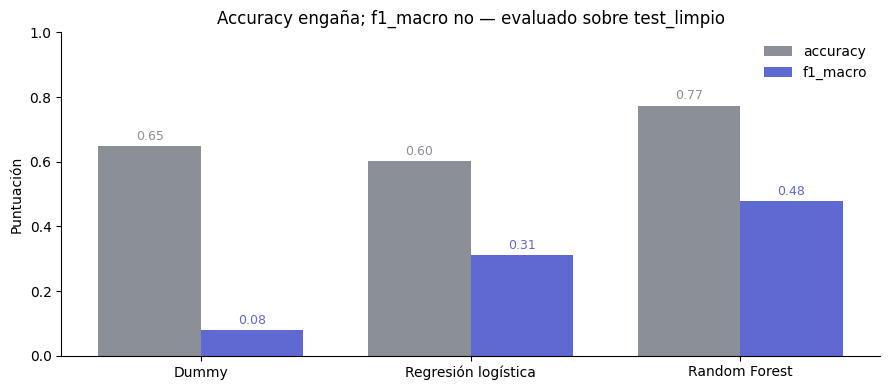

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
posicion = np.arange(len(comparativa))
ancho = 0.38

ax.bar(posicion - ancho / 2, comparativa["accuracy"], ancho, label="accuracy", color=GRIS)
ax.bar(posicion + ancho / 2, comparativa["f1_macro"], ancho, label="f1_macro", color=ACENTO)

ax.set_xticks(posicion, comparativa.index)
ax.set_ylim(0, 1)
ax.set_ylabel("Puntuación")
ax.set_title("Accuracy engaña; f1_macro no — evaluado sobre test_limpio")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)

for i, (a, f) in enumerate(zip(comparativa["accuracy"], comparativa["f1_macro"])):
    ax.text(i - ancho / 2, a + 0.02, f"{a:.2f}", ha="center", fontsize=9, color=GRIS)
    ax.text(i + ancho / 2, f + 0.02, f"{f:.2f}", ha="center", fontsize=9, color=ACENTO)

plt.tight_layout()
fig.savefig(RESULTADOS / "comparativa-modelos.png", dpi=140)
plt.show()

### Qué se ve aquí

**La barra gris apenas se mueve entre el modelo tonto y la regresión logística.**
Pasa de 0,65 a 0,60 — de hecho *baja*. Si solo se mirara el accuracy, se
concluiría que la regresión logística no aporta nada. La barra morada cuenta otra
historia: f1_macro sube de 0,08 a 0,31, casi cuatro veces. Es el mismo fenómeno
de la sección anterior, ahora con modelos de verdad.

**Random Forest gana en las dos métricas y por bastante**: 0,48 de f1_macro
frente a 0,31. Y además tarda alrededor de la mitad en entrenar, pese a estar
construyendo 200 árboles.

El motivo es el tipo de problema. Distinguir `Fuzzers` de `Exploits` depende de
combinaciones entre columnas —duración *junto con* número de paquetes *junto con*
protocolo—, y eso una frontera recta no lo captura. Los árboles sí.

> **Decisión: Random Forest como modelo de referencia.** La regresión logística
> se queda como término de comparación, no como candidata.

---

# 4. El precio de la fuga

Aquí se comprueba lo que el cuaderno anterior anticipaba: cuánto cambia el
resultado según se evalúe sobre la división oficial contaminada o sobre la
limpia.

In [10]:
fuga = pd.DataFrame([
    {"conjunto": "test_oficial (con fuga)", **evaluar(bosque, X_oficial, y_oficial)},
    {"conjunto": "test_limpio (sin fuga)", **evaluar(bosque, X_limpio, y_limpio)},
]).set_index("conjunto").round(4)

fuga

,accuracy,f1_macro,f1_weighted
conjunto,,,
test_oficial (con fuga),0.7530,0.4570,0.7740
test_limpio (sin fuga),0.7735,0.4773,0.7887


### Un resultado que no cuadra

**Todas las métricas son mejores en el conjunto limpio.** El accuracy sube de
0,753 a 0,774 y el f1_macro de 0,457 a 0,477.

Esto es lo contrario de lo que debería pasar. Si `test_oficial` contiene 20 851
filas que el modelo ya vio durante el entrenamiento, esas filas deberían ser
regalos: ejemplos memorizados que inflan la puntuación. Al quitarlos, la métrica
tendría que **bajar**.

Sube. Así que la explicación de partida —«la fuga infla los resultados»— está
incompleta. Antes de escribir ninguna conclusión hay que averiguar por qué.

El primer sitio donde mirar es el **reparto de clases**: al eliminar filas se
cambió la composición del conjunto.

In [11]:
reparto = pd.DataFrame({
    "% en oficial": test_oficial[OBJETIVO].value_counts(normalize=True) * 100,
    "% en limpio": test_limpio[OBJETIVO].value_counts(normalize=True) * 100,
    "filas en oficial": test_oficial[OBJETIVO].value_counts(),
    "filas en limpio": test_limpio[OBJETIVO].value_counts(),
})
reparto["cambio_pp"] = (reparto["% en limpio"] - reparto["% en oficial"]).round(2)
reparto.round(2).sort_values("cambio_pp")

,% en oficial,% en limpio,filas en oficial,filas en limpio,cambio_pp
attack_cat,,,,,
Generic,22.92,2.59,18871,1234,-20.33
DoS,4.97,2.89,4089,1378,-2.08
Analysis,0.82,0.52,677,250,-0.30
Reconnaissance,4.25,4.01,3496,1912,-0.24
Backdoor,0.71,0.56,583,267,-0.15
Worms,0.05,0.09,44,41,0.03
Shellcode,0.46,0.61,378,291,0.15
Fuzzers,7.36,8.67,6062,4139,1.31
Exploits,13.52,15.26,11132,7280,1.74


### Primera pieza: el examen cambió de contenido

`Generic` **pasa del 22,9 % al 2,6 %** del conjunto de prueba. `Normal`, en
cambio, sube del 44,9 % al 64,8 %.

Es decir: el conjunto limpio tiene proporcionalmente muchas más filas de la clase
más fácil. Eso explica parte de la subida del accuracy.

> **Lección práctica:** comparar accuracy entre dos conjuntos con distinta
> composición no significa nada. La métrica subió porque el examen tenía más
> preguntas fáciles, no porque el modelo mejorara.

Pero esto **no explica que el f1_macro también suba**, porque el f1_macro trata a
todas las clases por igual y no depende de su tamaño. Falta algo. Para verlo hay
que bajar al recall por clase.

In [12]:
clases = sorted(y_train.unique())

recall_oficial = recall_score(y_oficial, bosque.predict(X_oficial),
                              average=None, labels=clases, zero_division=0)
recall_limpio = recall_score(y_limpio, bosque.predict(X_limpio),
                             average=None, labels=clases, zero_division=0)

por_clase = pd.DataFrame({
    "recall_oficial": recall_oficial,
    "recall_limpio": recall_limpio,
    "ejemplos_en_limpio": [int((y_limpio == c).sum()) for c in clases],
}, index=clases)
por_clase["diferencia"] = (por_clase["recall_limpio"] - por_clase["recall_oficial"]).round(3)

por_clase.round(3).sort_values("diferencia")

,recall_oficial,recall_limpio,ejemplos_en_limpio,diferencia
Generic,0.970,0.585,1234,-0.385
Shellcode,0.474,0.385,291,-0.089
Worms,0.114,0.073,41,-0.040
Analysis,0.056,0.056,250,-0.000
Normal,0.786,0.808,30924,0.022
Backdoor,0.221,0.288,267,0.067
Reconnaissance,0.723,0.794,1912,0.071
DoS,0.159,0.239,1378,0.080
Fuzzers,0.584,0.669,4139,0.085
Exploits,0.678,0.877,7280,0.199


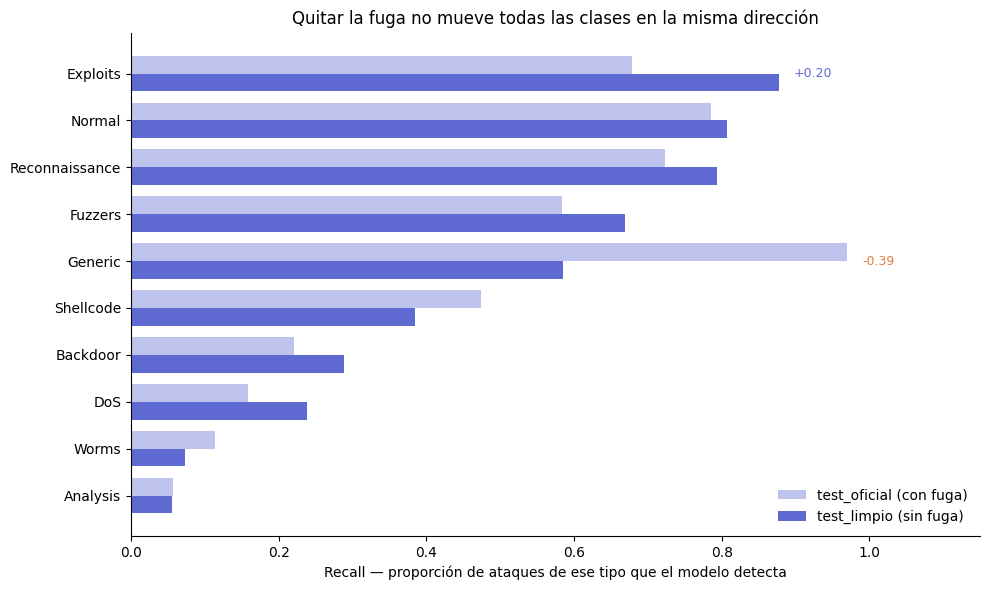

In [13]:
orden = por_clase.sort_values("recall_limpio").index
posicion = np.arange(len(orden))
alto = 0.38

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(posicion + alto / 2, por_clase.loc[orden, "recall_oficial"], alto,
        label="test_oficial (con fuga)", color=ACENTO, alpha=0.40)
ax.barh(posicion - alto / 2, por_clase.loc[orden, "recall_limpio"], alto,
        label="test_limpio (sin fuga)", color=ACENTO)

ax.set_yticks(posicion, orden)
ax.set_xlim(0, 1.15)
ax.set_xlabel("Recall — proporción de ataques de ese tipo que el modelo detecta")
ax.set_title("Quitar la fuga no mueve todas las clases en la misma dirección")
ax.legend(frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)

# Se anotan los movimientos grandes, en cualquiera de los dos sentidos.
for i, clase in enumerate(orden):
    diferencia = por_clase.loc[clase, "diferencia"]
    if abs(diferencia) >= 0.15:
        referencia = max(por_clase.loc[clase, "recall_oficial"],
                         por_clase.loc[clase, "recall_limpio"])
        ax.text(referencia + 0.02, i, f"{diferencia:+.2f}", va="center", fontsize=9,
                color=AVISO if diferencia < 0 else ACENTO)

plt.tight_layout()
fig.savefig(RESULTADOS / "recall-fuga.png", dpi=140)
plt.show()

### Segunda pieza: las clases se mueven en direcciones opuestas

Este gráfico es el más informativo del cuaderno, porque contradice la hipótesis
sencilla. Las barras claras son el conjunto contaminado; las sólidas, el limpio.

**Bajan al limpiar:**
- `Generic` se desploma de **0,970 a 0,585**. Treinta y nueve puntos.
- `Shellcode` −0,089 y `Worms` −0,040.

**Suben al limpiar:**
- `Exploits` de 0,678 a **0,877** (+0,199).
- `Fuzzers` +0,085, `DoS` +0,080, `Reconnaissance` +0,071, `Backdoor` +0,067.

`Generic` se comporta como cabía esperar: era la clase con más filas filtradas en
términos absolutos y el modelo las tenía memorizadas. Quitadas, falla cuatro de
cada diez. **Eso sí es fuga inflando el resultado.**

Lo que no cuadra es `DoS` y `Exploits`. Si sus filas filtradas estaban
memorizadas, quitarlas debería bajarles el recall. Lo sube. **La única
explicación posible es que esas filas filtradas no fueran aciertos regalados,
sino fallos inevitables.** Se comprueba a continuación.

---

# 5. El tercer problema: etiquetas contradictorias

La hipótesis a comprobar: entre las filas filtradas hay algunas cuyo **vector de
características idéntico aparece en entrenamiento con otra etiqueta**.

Si eso ocurre, el modelo no puede acertarlas. Ve exactamente las mismas 34
características que vio al entrenar y responde lo que aprendió; pero la respuesta
correcta es otra. Son fallos garantizados.

Se comprueba comparando cada fila filtrada con el conjunto de etiquetas que su
vector tiene en entrenamiento.

In [14]:
# Se construye una clave de texto por fila para poder comparar vectores completos.
def clave(df):
    """Devuelve una serie con las 34 características concatenadas como texto."""
    return df[CARACTERISTICAS].astype(str).agg("|".join, axis=1)


clave_train = clave(train)
clave_oficial = clave(test_oficial)

# Para cada vector de entrenamiento, el conjunto de etiquetas que lleva asociadas.
etiquetas_por_vector = train.assign(_k=clave_train).groupby("_k")[OBJETIVO].agg(set)

ambiguos = etiquetas_por_vector[etiquetas_por_vector.map(len) > 1]
filas_ambiguas = clave_train.isin(ambiguos.index).sum()

print(f"Vectores únicos en entrenamiento:  {len(etiquetas_por_vector):>7,}")
print(f"Vectores con MAS de una etiqueta:  {len(ambiguos):>7,}")
print(f"Filas de entrenamiento afectadas:  {filas_ambiguas:>7,}")

Vectores únicos en entrenamiento:   92,098
Vectores con MAS de una etiqueta:    1,397
Filas de entrenamiento afectadas:    6,121


In [15]:
# Las filas de test_oficial que ya estaban en entrenamiento: ¿coincide su etiqueta?
filtradas = test_oficial[clave_oficial.isin(etiquetas_por_vector.index)].copy()
filtradas["etiquetas_en_train"] = clave_oficial[filtradas.index].map(etiquetas_por_vector)

# Una fila es contradictoria si su etiqueta real NO figura entre las que el
# modelo pudo aprender para ese mismo vector de características.
filtradas["contradictoria"] = [
    fila.attack_cat not in fila.etiquetas_en_train for fila in filtradas.itertuples()
]

print(f"Filas filtradas (presentes en entrenamiento): {len(filtradas):,}")
print(f"De ellas, con etiqueta CONTRADICTORIA:        "
      f"{filtradas['contradictoria'].sum():,} "
      f"({filtradas['contradictoria'].mean():.1%})")

Filas filtradas (presentes en entrenamiento): 20,851
De ellas, con etiqueta CONTRADICTORIA:        2,255 (10.8%)


In [16]:
contradiccion = filtradas.groupby(OBJETIVO, observed=True)["contradictoria"].agg(
    filtradas="size", contradictorias="sum"
)
contradiccion["% contradictorias"] = (
    contradiccion["contradictorias"] / contradiccion["filtradas"] * 100
).round(1)

# Se une al movimiento de recall para poder mirar las dos cosas a la vez.
contradiccion = contradiccion.join(por_clase[["diferencia"]]).sort_values(
    "% contradictorias", ascending=False
)
contradiccion

,filtradas,contradictorias,% contradictorias,diferencia
attack_cat,,,,
DoS,2198,848,38.6,0.080
Exploits,2114,796,37.7,0.199
Worms,3,1,33.3,-0.040
Analysis,248,75,30.2,-0.000
Shellcode,84,12,14.3,-0.089
Fuzzers,956,118,12.3,0.085
Reconnaissance,1539,114,7.4,0.071
Normal,4399,265,6.0,0.022
Backdoor,127,1,0.8,0.067


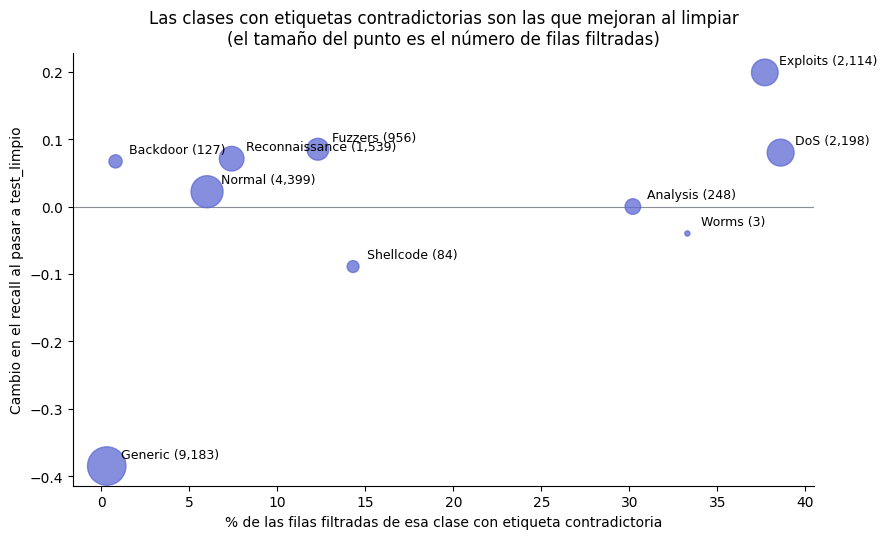

In [17]:
# ¿Las clases con más etiquetas contradictorias son las que mejoran al limpiar?
datos = contradiccion.dropna(subset=["diferencia"])

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.axhline(0, color=GRIS, linewidth=0.8)
# El tamaño del punto refleja cuántas filas filtradas tiene la clase: los puntos
# pequeños se apoyan en tan pocos casos que su posición es ruido.
ax.scatter(datos["% contradictorias"], datos["diferencia"],
           s=np.sqrt(datos["filtradas"]) * 8, color=ACENTO, alpha=0.75, zorder=3)

for clase, fila in datos.iterrows():
    ax.annotate(f"{clase} ({int(fila['filtradas']):,})",
                (fila["% contradictorias"], fila["diferencia"]),
                textcoords="offset points", xytext=(10, 6), fontsize=9)

ax.set_xlabel("% de las filas filtradas de esa clase con etiqueta contradictoria")
ax.set_ylabel("Cambio en el recall al pasar a test_limpio")
ax.set_title("Las clases con etiquetas contradictorias son las que mejoran al limpiar\n"
             "(el tamaño del punto es el número de filas filtradas)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(RESULTADOS / "etiquetas-contradictorias.png", dpi=140)
plt.show()

### Qué se ve aquí — la hipótesis se confirma

**1 397 vectores de características de entrenamiento llevan más de una etiqueta**,
y afectan a 6 121 filas. Son conexiones descritas con valores idénticos en las 34
columnas pero clasificadas como ataques de tipos distintos.

De las 20 851 filas filtradas, **2 255 (10,8 %) tienen una etiqueta que
contradice todo lo que el modelo pudo aprender para ese vector**. Y no se
reparten por igual:

| Clase | % de sus filas filtradas que son contradictorias | Cambio de recall al limpiar |
|---|---|---|
| DoS | **38,6 %** | +0,080 |
| Exploits | **37,7 %** | +0,199 |
| Analysis | 30,2 % | −0,000 |
| Fuzzers | 12,3 % | +0,085 |
| Normal | 6,0 % | +0,022 |
| **Generic** | **0,3 %** | **−0,385** |

El gráfico de dispersión cierra el razonamiento: **las clases con más
contradicciones son, en general, las que suben el recall al limpiar.** `DoS` y
`Exploits` arriba a la derecha; `Generic`, con solo un 0,3 % de contradicciones,
sola abajo a la izquierda.

**Dos clases no siguen el patrón, y conviene decirlo:** `Worms` aparece en el
33,3 % de contradicciones, pero eso son **1 fila de 3** — la cifra no tiene
ningún valor estadístico. `Shellcode` (14,3 % sobre 84 filas) también va a
contracorriente. Ambas tienen tan pocas filas filtradas que su posición en el
gráfico es ruido. La relación se sostiene en las clases con volumen suficiente,
que son las que mueven el f1_macro.

### Lo que esto significa

La fuga de UNSW-NB15 no actúa de una sola manera. Hace **dos cosas opuestas** a
la vez:

1. **Regala aciertos** en las clases cuyas filas duplicadas son consistentes
   (`Generic`). Ahí infla el resultado, que es el efecto que todo el mundo
   espera.
2. **Regala fallos** en las clases cuyas filas duplicadas tienen etiquetas
   contradictorias (`DoS`, `Exploits`, `Analysis`). Ahí lo deprime, porque
   ningún modelo puede acertarlas.

Sobre el conjunto oficial esos dos efectos se cancelan en parte, y el resultado
agregado parece razonable. **Una métrica publicada sobre la división oficial no
es simplemente «demasiado optimista»: es incomparable, porque mezcla puntuación
regalada con puntuación imposible.**

> **Hallazgo principal del proyecto.** Y también un límite real: mientras existan
> vectores idénticos con etiquetas distintas hay un techo de acierto que ningún
> modelo puede superar. No es un problema de modelado, es un problema de
> etiquetado en el origen.

---

# 6. Dónde se equivoca el modelo

Las métricas dicen *cuánto* falla. La matriz de confusión dice *con qué lo
confunde*, que es lo que permite mejorarlo.

Se normaliza por filas: cada fila suma 1 y muestra **en qué se repartieron los
ejemplos reales de esa clase**.

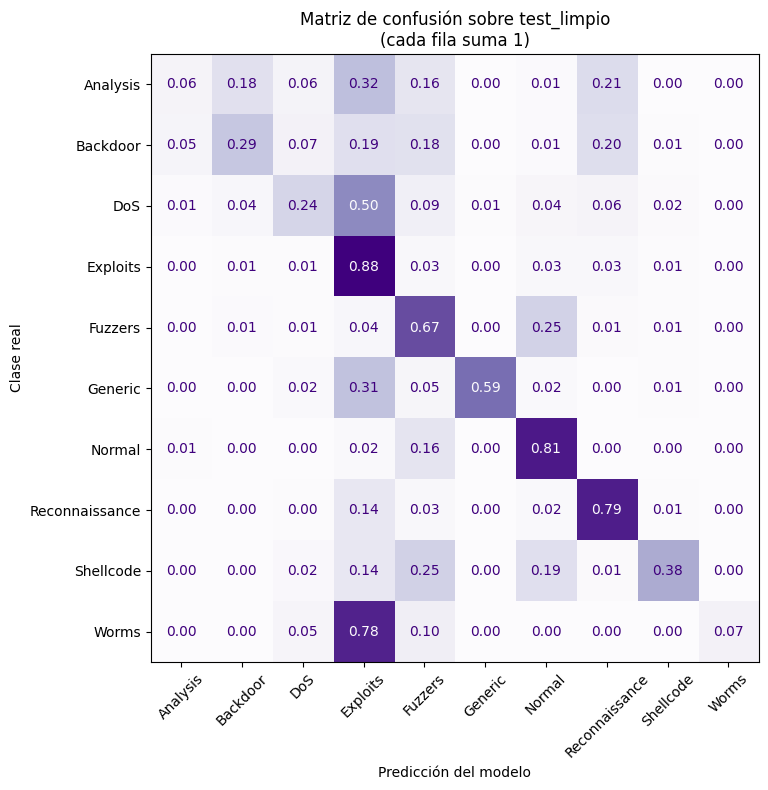

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

matriz = confusion_matrix(y_limpio, bosque.predict(X_limpio), labels=clases, normalize="true")

fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(matriz, display_labels=clases).plot(
    ax=ax, cmap="Purples", colorbar=False, values_format=".2f", xticks_rotation=45
)
ax.set_title("Matriz de confusión sobre test_limpio\n(cada fila suma 1)")
ax.set_xlabel("Predicción del modelo")
ax.set_ylabel("Clase real")
plt.tight_layout()
fig.savefig(RESULTADOS / "matriz-confusion.png", dpi=140)
plt.show()

In [19]:
# Para cada clase, con qué otra se la confunde más a menudo.
confusiones = []
for i, clase in enumerate(clases):
    fila = matriz[i].copy()
    fila[i] = 0  # se ignora el acierto para quedarse con el error principal
    j = int(fila.argmax())
    confusiones.append({
        "clase_real": clase,
        "acierta": round(matriz[i, i], 3),
        "se_confunde_sobre_todo_con": clases[j],
        "proporcion": round(fila[j], 3),
        "ejemplos": int((y_limpio == clase).sum()),
    })

pd.DataFrame(confusiones).set_index("clase_real").sort_values("acierta")

,acierta,se_confunde_sobre_todo_con,proporcion,ejemplos
clase_real,,,,
Analysis,0.056,Exploits,0.320,250
Worms,0.073,Exploits,0.780,41
DoS,0.239,Exploits,0.498,1378
Backdoor,0.288,Reconnaissance,0.199,267
Shellcode,0.385,Fuzzers,0.251,291
Generic,0.585,Exploits,0.310,1234
Fuzzers,0.669,Normal,0.250,4139
Reconnaissance,0.794,Exploits,0.142,1912
Normal,0.808,Fuzzers,0.160,30924


### Qué se ve aquí

**`Exploits` es el sumidero del modelo.** Cinco de las diez clases —`Analysis`,
`Worms`, `DoS`, `Generic` y `Reconnaissance`— tienen `Exploits` como su error más
frecuente. Cuando el bosque duda, dice `Exploits`, porque es la clase de ataque
con más ejemplos de entrenamiento (19 360).

**`Worms` es el caso extremo: acierta 3 de 41, y el 78 % acaba en `Exploits`.**
Con 123 ejemplos de entrenamiento el modelo apenas tiene de dónde aprender.
Confirma la tesis del proyecto: un accuracy global de 0,774 convive con una clase
que prácticamente no existe para el modelo.

**`Analysis` acierta 0,056** — 14 de 250. El 32 % va a `Exploits` y el resto se
dispersa. Tiene sentido desde el dominio: la fase de análisis de un ataque genera
tráfico parecido al del exploit que viene después. Puede que la frontera entre
esas clases no exista en los datos.

**`DoS` acierta 0,239 y manda el 49,8 % a `Exploits`.** Es la confusión más grande
entre clases con muchos ejemplos, y la primera candidata a mejorar. También es la
clase con más etiquetas contradictorias (38,6 %), así que parte de ese error puede
no tener solución.

**`Backdoor` (0,288) se dispersa**, con `Reconnaissance` como error principal
(19,9 %) — es la única clase que no cae hacia `Exploits`.

**Solo `Normal` (0,808) y `Exploits` (0,877) funcionan bien**, y las dos por el
mismo motivo: son las que más ejemplos tienen. `Generic`, que sobre el conjunto
oficial parecía casi perfecta, se queda en 0,585.

> **Lo importante:** los errores no están repartidos al azar. Casi todos apuntan
> a la misma clase mayoritaria. Eso orienta el siguiente paso —compensar el
> desequilibrio— mucho mejor que cualquier número global.

---

# Resumen

## Decisiones tomadas

| Decisión | Elegido | Descartado, y por qué |
|---|---|---|
| Codificación | **Ordinal** | One-Hot (186 columnas), Target (riesgo de fuga), Frequency (pierde identidad) |
| Categorías nuevas | `unknown_value=-1` | Dejar que lance excepción: fallaría en producción |
| Escalado | Solo para el modelo lineal | Innecesario en árboles |
| Métrica principal | **f1_macro** + recall por clase | accuracy (la domina la clase mayoritaria) |
| Modelo de referencia | **Random Forest** | Logística (peor y más lenta), redes, SVM, k-NN |

## Resultados de referencia — sobre `test_limpio`

| Modelo | accuracy | f1_macro |
|---|---|---|
| Dummy (siempre «Normal») | 0,648 | 0,079 |
| Regresión logística | 0,602 | 0,310 |
| **Random Forest** | **0,774** | **0,477** |

## Los cuatro hallazgos

1. **Un modelo que no aprende nada saca 0,648 de accuracy.** Cualquier lectura
   basada en esa métrica es inútil aquí.

2. **Quitar la fuga mejora las métricas en lugar de empeorarlas.** Lo contrario
   de lo esperado, y la razón obliga a investigar antes de reportar.

3. **UNSW-NB15 tiene etiquetas contradictorias: 1 397 vectores de
   características idénticos con más de una etiqueta.** Por eso la fuga regala
   aciertos en `Generic` (0,3 % de contradicciones, recall −0,385 al limpiar) y
   regala fallos en `DoS` y `Exploits` (38,6 % y 37,7 %, recall +0,080 y +0,199).
   Los dos efectos se cancelan en parte y el número agregado engaña.

4. **El error se concentra: `Exploits` es el sumidero.** Cinco clases lo tienen
   como error principal. `Worms` manda ahí el 78 % de sus casos.

## Siguiente paso

Con 0,477 de f1_macro hay margen de sobra, y ya se sabe dónde atacar: evitar que
todo caiga hacia `Exploits`.

- Aplicar técnicas contra el desequilibrio —`class_weight="balanced"`, SMOTE y
  submuestreo— y **comparar las tres** sobre la misma partición limpia.
- Cuantificar el techo que imponen las etiquetas contradictorias, para saber qué
  parte del error es irreducible.
- Probar un modelo de *boosting*, que suele rendir algo mejor que un bosque
  aleatorio en datos tabulares.

La cifra que hay que mover es el **recall de las clases raras**, no el accuracy.
